In [52]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import matplotlib.dates as mdates


In [53]:
# ============================================================
# 1. Configuration
# ============================================================

# Dossier principal contenant les datasets
DATASET_PATH = Path("dataset")

# Correspondance année -> dossier
YEAR_FOLDERS = {
    2016: "Kelmarsh_SCADA_2016_3082",
    2017: "Kelmarsh_SCADA_2017_3083",
    2018: "Kelmarsh_SCADA_2018_3084",
    2019: "Kelmarsh_SCADA_2019_3085",
    2020: "Kelmarsh_SCADA_2020_3086",
}

# Numéro de la turbine
TURBINE_ID = 1

In [54]:
# ============================================================
# 2. Chargement des données
# ============================================================

data_dfs = []
status_dfs = []

for year, folder_name in YEAR_FOLDERS.items():

    folder_path = DATASET_PATH / folder_name

    # Recherche des fichiers de la turbine 1
    data_files = list(folder_path.glob(
        f"Turbine_Data_Kelmarsh_{TURBINE_ID}_*.csv"
    ))

    status_files = list(folder_path.glob(
        f"Status_Kelmarsh_{TURBINE_ID}_*.csv"
    ))

    # Vérification
    print(f"\n{'=' * 60}")
    print(f"Année : {year}")
    print(f"Dossier : {folder_path}")

    print(f"Fichier(s) data trouvé(s)   : {len(data_files)}")
    print(f"Fichier(s) status trouvé(s) : {len(status_files)}")

    # --------------------------------------------------------
    # Chargement des données SCADA
    # --------------------------------------------------------

    for file in data_files:
        print(f"  Data   -> {file.name}")

        df = pd.read_csv(file)

        # On ajoute l'année et la turbine comme informations
        # supplémentaires
        df["Year"] = year
        df["Turbine"] = TURBINE_ID

        data_dfs.append(df)

    # --------------------------------------------------------
    # Chargement des données de statut
    # --------------------------------------------------------

    for file in status_files:
        print(f"  Status -> {file.name}")

        df = pd.read_csv(file)

        df["Year"] = year
        df["Turbine"] = TURBINE_ID

        status_dfs.append(df)


Année : 2016
Dossier : dataset\Kelmarsh_SCADA_2016_3082
Fichier(s) data trouvé(s)   : 1
Fichier(s) status trouvé(s) : 1
  Data   -> Turbine_Data_Kelmarsh_1_2016-01-03_-_2017-01-01_228.csv
  Status -> Status_Kelmarsh_1_2016-01-03_-_2017-01-01_228.csv

Année : 2017
Dossier : dataset\Kelmarsh_SCADA_2017_3083
Fichier(s) data trouvé(s)   : 1
Fichier(s) status trouvé(s) : 1
  Data   -> Turbine_Data_Kelmarsh_1_2017-01-01_-_2018-01-01_228.csv
  Status -> Status_Kelmarsh_1_2017-01-01_-_2018-01-01_228.csv

Année : 2018
Dossier : dataset\Kelmarsh_SCADA_2018_3084
Fichier(s) data trouvé(s)   : 1
Fichier(s) status trouvé(s) : 1
  Data   -> Turbine_Data_Kelmarsh_1_2018-01-01_-_2019-01-01_228.csv
  Status -> Status_Kelmarsh_1_2018-01-01_-_2019-01-01_228.csv

Année : 2019
Dossier : dataset\Kelmarsh_SCADA_2019_3085
Fichier(s) data trouvé(s)   : 1
Fichier(s) status trouvé(s) : 1
  Data   -> Turbine_Data_Kelmarsh_1_2019-01-01_-_2020-01-01_228.csv
  Status -> Status_Kelmarsh_1_2019-01-01_-_2020-01-01_228.

In [55]:
# ============================================================
# 3. Fusion des années
# ============================================================

df_data = pd.concat(
    data_dfs,
    ignore_index=True
)

df_status = pd.concat(
    status_dfs,
    ignore_index=True
)

In [56]:
# ============================================================
# 4. Informations générales
# ============================================================

print("\n" + "=" * 60)
print("CHARGEMENT TERMINÉ")
print("=" * 60)

print(f"\nData Kelmarsh :")
print(f"Nombre de lignes : {len(df_data):,}")
print(f"Nombre de colonnes : {len(df_data.columns)}")

print(f"\nStatus :")
print(f"Nombre de lignes : {len(df_status):,}")
print(f"Nombre de colonnes : {len(df_status.columns)}")


CHARGEMENT TERMINÉ

Data Kelmarsh :
Nombre de lignes : 262,800
Nombre de colonnes : 301

Status :
Nombre de lignes : 36,719
Nombre de colonnes : 11


In [57]:
display(df_data.head())
print(df_data.shape)

,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,"Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)",Year,Turbine
0,2016-01-03 00:00:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
1,2016-01-03 00:10:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
2,2016-01-03 00:20:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
3,2016-01-03 00:30:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1
4,2016-01-03 00:40:00,NaN,NaN,NaN,NaN,7.1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016,1


(262800, 301)


In [58]:
nan_data = pd.DataFrame({
    "Nom": df_data.columns,
    "Nombre NaN": df_data.isna().sum().values,
    "Pourcentage NaN": (df_data.isna().mean().values * 100),
    "colums_type" :(df_data.dtypes)
}).T

display(nan_data)

,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,"Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)",Year,Turbine
Nom,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,"Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)",Year,Turbine
Nombre NaN,0,6916,95827,95827,95827,0,78561,96108,97491,96108,...,214479,214479,214479,214492,214492,214492,214479,214479,0,0
Pourcentage NaN,0.0,2.631659,36.463851,36.463851,36.463851,0.0,29.893836,36.570776,37.097032,36.570776,...,81.613014,81.613014,81.613014,81.61796,81.61796,81.61796,81.613014,81.613014,0.0,0.0
colums_type,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,...,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64


In [59]:
# Colonnes complètement vides
cols_100_nan = df_data.columns[df_data.isna().all()]

print("Colonnes avec 100% de NaN :")
print(cols_100_nan.tolist())

# Suppression
df_data = df_data.drop(columns=cols_100_nan)

Colonnes avec 100% de NaN :
['Lost Production (Contractual Global) (kWh)', 'Lost Production (Contractual Custom) (kWh)', 'Potential power met mast anemometer (kW)', 'Potential power met mast anemometer MPC (kW)', 'Time-based Contractual Avail. (Global)', 'Time-based Contractual Avail. (Custom)', 'Production-based Contractual Avail. (Global)', 'Production-based Contractual Avail. (Custom)', 'Equivalent Full Load Hours counter (s)']


In [60]:
for i, col in enumerate(df_data.columns, start=1):
    print(f"{i:3} - {col}")

  1 - Date and time
  2 - Wind speed (m/s)
  3 - Wind speed, Standard deviation (m/s)
  4 - Wind speed, Minimum (m/s)
  5 - Wind speed, Maximum (m/s)
  6 - Long Term Wind (m/s)
  7 - Wind speed Sensor 1 (m/s)
  8 - Wind speed Sensor 1, Standard deviation (m/s)
  9 - Wind speed Sensor 1, Minimum (m/s)
 10 - Wind speed Sensor 1, Maximum (m/s)
 11 - Wind speed Sensor 2 (m/s)
 12 - Wind speed Sensor 2, Standard deviation (m/s)
 13 - Wind speed Sensor 2, Minimum (m/s)
 14 - Wind speed Sensor 2, Maximum (m/s)
 15 - Density adjusted wind speed (m/s)
 16 - Wind direction (°)
 17 - Nacelle position (°)
 18 - Wind direction, Standard deviation (°)
 19 - Wind direction, Minimum (°)
 20 - Wind direction, Maximum (°)
 21 - Nacelle position, Standard deviation (°)
 22 - Nacelle position, Minimum (°)
 23 - Nacelle position, Maximum (°)
 24 - Vane position 1+2 (°)
 25 - Vane position 1+2, Max (°)
 26 - Vane position 1+2, Min (°)
 27 - Vane position 1+2, StdDev (°)
 28 - Energy Export (kWh)
 29 - Energ

In [61]:
display(df_status.head())
print(df_status.shape)

,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category,Year,Turbine
0,2016-01-14 19:28:03,2016-01-23 14:36:32,211:08:29,Stop,111,Emergency stop nacelle,NaN,Emergency stop switch (Nacelle) (11),Forced outage,2016,1
1,2016-01-14 19:28:03,2016-01-14 19:38:03,00:10:00,Warning,5720,Brake accumulator defect,NaN,Warnings (27),NaN,2016,1
2,2016-01-14 19:28:05,2016-01-23 11:27:46,207:59:41,Informational,3835,Cable panel breaker open,NaN,Warnings (27),NaN,2016,1
3,2016-01-14 19:28:05,2016-01-23 11:27:46,207:59:41,Informational,3830,Supply circuit breaker earthed,NaN,Warnings (27),Full Performance,2016,1
4,2016-01-14 19:28:05,2016-01-23 14:09:18,210:41:13,Warning,3870,Overload transformer fan outlet air,NaN,Warnings (27),Full Performance,2016,1


(36719, 11)


In [62]:
nan_data = pd.DataFrame({
    "Nombre NaN": df_data.isna().sum(),
    "Pourcentage NaN": df_data.isna().mean() * 100
}).T

display(nan_data)

,Date and time,Wind speed (m/s),"Wind speed, Standard deviation (m/s)","Wind speed, Minimum (m/s)","Wind speed, Maximum (m/s)",Long Term Wind (m/s),Wind speed Sensor 1 (m/s),"Wind speed Sensor 1, Standard deviation (m/s)","Wind speed Sensor 1, Minimum (m/s)","Wind speed Sensor 1, Maximum (m/s)",...,"Tower Acceleration X, Max (mm/ss)","Tower Acceleration Y, Min (mm/ss)","Tower Acceleration Y, Max (mm/ss)","Drive train acceleration, Max (mm/ss)","Drive train acceleration, Min (mm/ss)","Drive train acceleration, StdDev (mm/ss)","Tower Acceleration X, StdDev (mm/ss)","Tower Acceleration Y, StdDev (mm/ss)",Year,Turbine
Nombre NaN,0.0,6916.000000,95827.000000,95827.000000,95827.000000,0.0,78561.000000,96108.000000,97491.000000,96108.000000,...,214479.000000,214479.000000,214479.000000,214492.00000,214492.00000,214492.00000,214479.000000,214479.000000,0.0,0.0
Pourcentage NaN,0.0,2.631659,36.463851,36.463851,36.463851,0.0,29.893836,36.570776,37.097032,36.570776,...,81.613014,81.613014,81.613014,81.61796,81.61796,81.61796,81.613014,81.613014,0.0,0.0


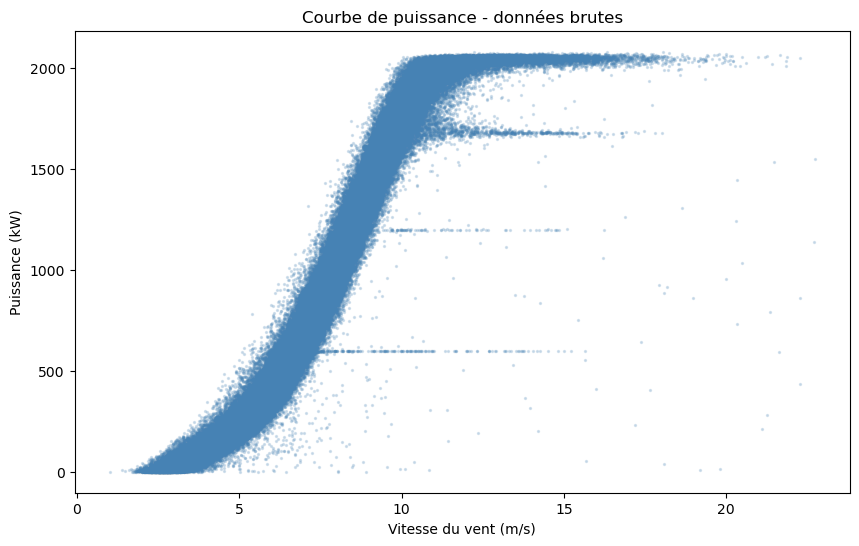

In [63]:


# Nettoyage minimal : on garde uniquement les lignes où la turbine produisait
# (on exclut les arrêts, qui ne sont pas des points de courbe de puissance valides)
df_clean = df_data[df_data["Data Availability"] > 0].copy()

# On peut aussi filtrer les valeurs de puissance négatives ou aberrantes
df_clean = df_clean[df_clean["Power (kW)"] >= 0]

# --- Version 1 : nuage de points brut ---
plt.figure(figsize=(10, 6))
plt.scatter(df_clean["Wind speed (m/s)"], df_clean["Power (kW)"],
            s=2, alpha=0.2, color="steelblue")
plt.xlabel("Vitesse du vent (m/s)")
plt.ylabel("Puissance (kW)")
plt.title("Courbe de puissance - données brutes")
plt.show()

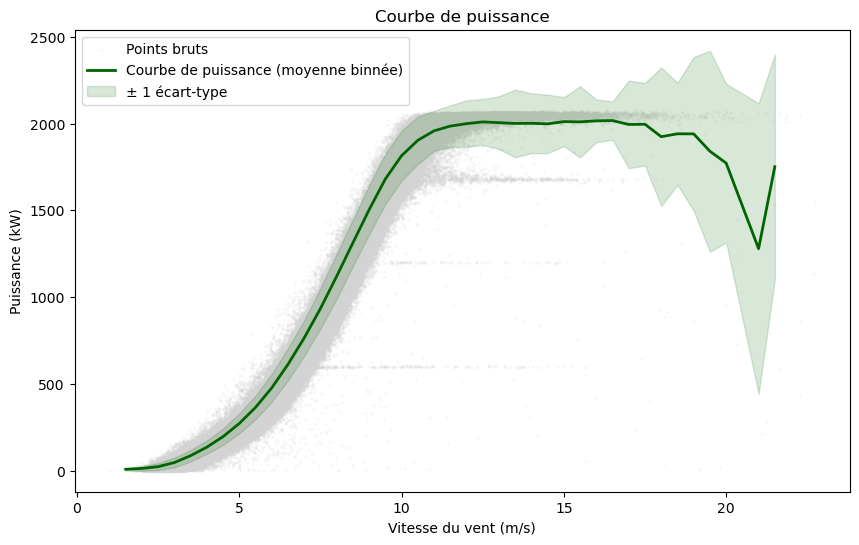

In [64]:
# --- Version 2 : courbe binnée (méthode revue scientifique) ---
bin_width = 0.5  # tranches de 0.5 m/s, standard IEC d apres le papier
df_clean["wind_bin"] = (df_clean["Wind speed (m/s)"] // bin_width) * bin_width

power_curve = df_clean.groupby("wind_bin")["Power (kW)"].agg(["mean", "std", "count"]).reset_index()
power_curve = power_curve[power_curve["count"] >= 5]  # on ignore les bins avec trop peu de points

plt.figure(figsize=(10, 6))
plt.scatter(df_clean["Wind speed (m/s)"], df_clean["Power (kW)"],
            s=2, alpha=0.1, color="lightgray", label="Points bruts")
plt.plot(power_curve["wind_bin"], power_curve["mean"],
          color="darkgreen", linewidth=2, label="Courbe de puissance (moyenne binnée)")
plt.fill_between(power_curve["wind_bin"],
                  power_curve["mean"] - power_curve["std"],
                  power_curve["mean"] + power_curve["std"],
                  color="darkgreen", alpha=0.15, label="± 1 écart-type")
plt.xlabel("Vitesse du vent (m/s)")
plt.ylabel("Puissance (kW)")
plt.title("Courbe de puissance")
plt.legend()
plt.show()

In [67]:


# --- 1. Sélection et nettoyage ---
features = [
    "Wind speed (m/s)",
    "Power (kW)",
    "Rotor speed (RPM)",
    "Gear oil temperature (°C)",
    "Generator bearing front temperature (°C)",
    "Nacelle temperature (°C)",
    "Blade angle (pitch position) A (°)",
]

df_if = df_clean.dropna(subset=features).copy()
X = df_if[features]

print(f"Lignes utilisées : {len(df_if)} / {len(df_clean)}")

# --- 2. Standardisation ---
# Important : Isolation Forest se base sur des seuils de partitionnement,
# la standardisation n'est pas strictement obligatoire (contrairement à KNN/SVM),
# mais elle aide à équilibrer l'influence de variables à échelles très différentes
# (ex: température en dizaines vs puissance en milliers).
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 3. Entraînement ---
# contamination : proportion attendue d'anomalies dans les données.
# 0.01-0.02 est un point de départ raisonnable (les vraies
# pannes/dérives sont rares) ; à ajuster 
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42,
    n_jobs=-1,
)

df_if["anomaly_score"] = iso_forest.fit_predict(X_scaled)  # -1 = anomalie, 1 = normal
df_if["anomaly_score_raw"] = iso_forest.decision_function(X_scaled)  # score continu (plus bas = plus anormal)

n_anomalies = (df_if["anomaly_score"] == -1).sum()
print(f"Anomalies détectées : {n_anomalies} ({n_anomalies/len(df_if)*100:.2f}%)")

Lignes utilisées : 216297 / 229457
Anomalies détectées : 2163 (1.00%)


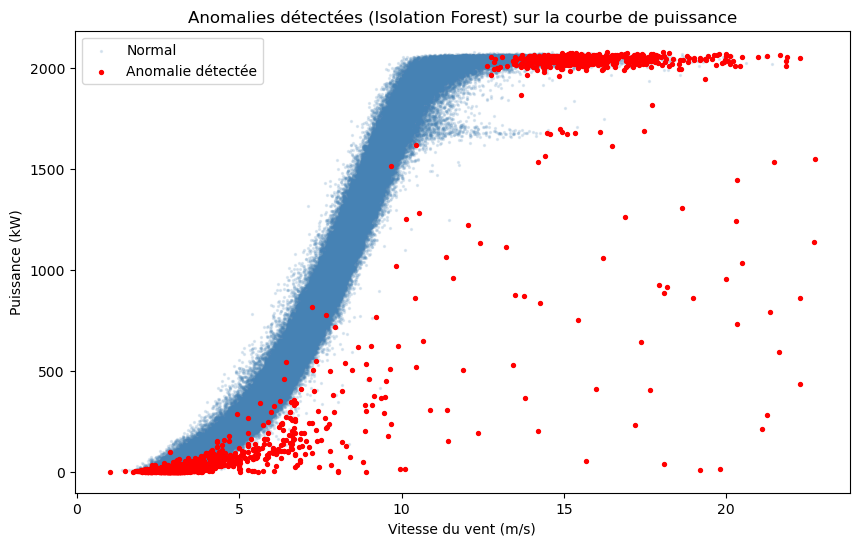

Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 7817 ticks ([-10806.0, ..., 227089.0]), which exceeds Locator.MAXTICKS (1000).
Locator at

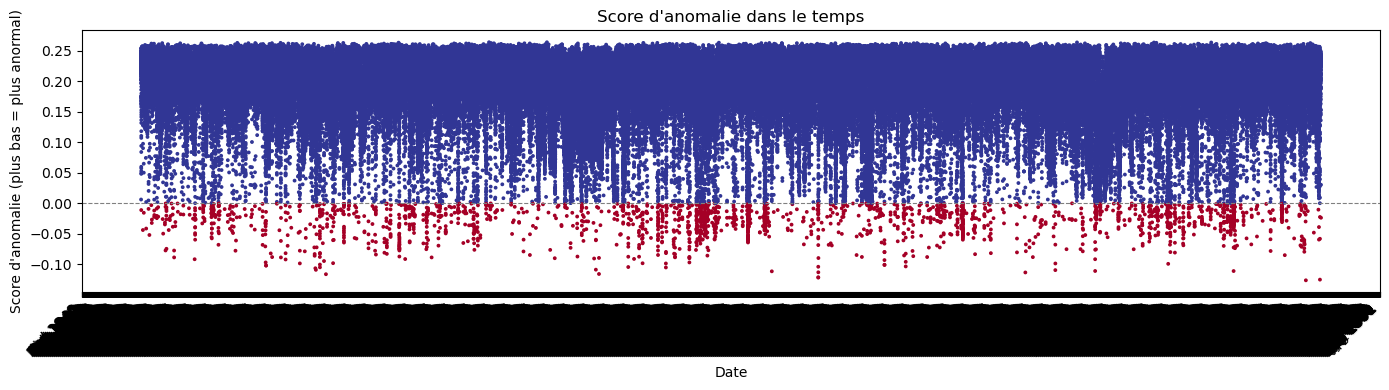

In [68]:
# --- Vue 1 : sur la courbe de puissance, pour repérer visuellement le lien avec le vent ---
plt.figure(figsize=(10, 6))
normal = df_if[df_if["anomaly_score"] == 1]
anomalies = df_if[df_if["anomaly_score"] == -1]

plt.scatter(normal["Wind speed (m/s)"], normal["Power (kW)"],
            s=2, alpha=0.15, color="steelblue", label="Normal")
plt.scatter(anomalies["Wind speed (m/s)"], anomalies["Power (kW)"],
            s=8, color="red", label="Anomalie détectée")
plt.xlabel("Vitesse du vent (m/s)")
plt.ylabel("Puissance (kW)")
plt.title("Anomalies détectées (Isolation Forest) sur la courbe de puissance")
plt.legend()
plt.show()

# --- Vue 2 : dans le temps, pour repérer des clusters (= vraie panne probable) ---
# vs anomalies isolées (= plus probablement du bruit ponctuel)
fig, ax = plt.subplots(figsize=(14, 4))
scatter = ax.scatter(df_if["Date and time"], df_if["anomaly_score_raw"],
                      c=df_if["anomaly_score"], cmap="RdYlBu", s=3)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

# Un tick par mois seulement, format lisible
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

ax.set_xlabel("Date")
ax.set_ylabel("Score d'anomalie (plus bas = plus anormal)")
ax.set_title("Score d'anomalie dans le temps")
plt.tight_layout()
plt.show()